# CAB420 Assignment 1A Question 3: Training and Adapting Deep Networks
Simon Denman (s.denman@qut.edu.au)

## Overview

This notebook provides a quick demo and overview of the provided utility functions to help with Assignment 1A, Question 3.

It also implements the SVM that you are to compare against when responsing to the question.

Please make sure you read the assignment brief on canvas, and check the FAQ for other information.

**Note: File paths used in this template may need to change for your local machine. Please set these based on your local file system structure.**

## Utility Functions

The following cell contains utility functions to:
* Load the data
* Vectorise the data
* Plot images
* Resize all images
* Convert images to grayscale

These are provided to assist you in developing your solution.

In [78]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [79]:
#
# Utility functions for CAB420, Assignment 1A, Q3
# Author: Simon Denman (s.denman@qut.edu.au)
#
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

from scipy.io import loadmat        # to load mat files
import matplotlib.pyplot as plt     # for plotting
import numpy as np                  # for reshaping, array manipulation
import cv2                          # for colour conversion
import tensorflow as tf             # for bulk image resize
import keras

# Load data for Q3
#  train_path: path to training data mat file
#  test_path:  path to testing data mat file
#
#  returns:    arrays for training and testing X and Y data
#
def load_data(train_path, val_path, test_path):

    # load files
    train = loadmat(train_path)
    val = loadmat(val_path)
    test = loadmat(test_path)

    # pull out training set and scale X data
    train_X = train['train_X'] / 255.0
    train_y = train['train_y'].reshape(-1)

    # pull out validation set and scale X data
    val_X = val['val_X'] / 255.0
    val_y = val['val_y'].reshape(-1)

    # pull out test set and scale X data
    test_X = test['test_X'] / 255.0
    test_y = test['test_y'].reshape(-1)

    # return loaded data
    return train_X, train_y, val_X, val_y, test_X, test_y

# vectorise an array of images, such that the shape is changed from {samples, width, height, channels} to
# (samples, width * height * channels)
#   images: array of images to vectorise
#
#   returns: vectorised array of images
#
def vectorise(images):
    # use numpy's reshape to vectorise the data
    return np.reshape(images, [len(images), -1])

# Plot some images and their labels. Will plot the first 100 samples in a 10x10 grid
#  x: array of images, of shape (samples, width, height, channels)
#  y: labels of the images
#
def plot_images(x, y):
    fig = plt.figure(figsize=[15, 18])
    for i in range(100):
        ax = fig.add_subplot(10, 10, i + 1)
        ax.imshow(x[i,:])
        ax.set_title(y[i])
        ax.axis('off')

# Resize an array of images
#  images:   array of images, of shape (samples, width, height, channels)
#  new_size: tuple of the new size, (new_width, new_height)
#
#  returns:  resized array of images, (samples, new_width, new_height, channels)
#
def resize(images, new_size):
    # tensorflow has an image resize funtion that can do this in bulk
    # note the conversion back to numpy after the resize
    return tf.image.resize(images, new_size).numpy()
          
# Convert images to grayscale
#   images:  array of colour images to convert, of size (samples, width, height, 3)
#
#   returns: array of converted images, of size (samples, width, height, 1)
#
def convert_to_grayscale(images):
    # storage for converted images
    gray = []
    # loop through images
    for i in range(len(images)):
        # convert each image using openCV
        gray.append(cv2.cvtColor(images[i,:], cv2.COLOR_BGR2GRAY))
    # pack converted list as an array and return
    return np.expand_dims(np.array(gray), axis = -1)

In [80]:
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Utility Function Demonstration

The following presents a brief demonstration of the utility functions. These portions of code do not form part of the template, or solution, and could be commented out/removed.

### Data Loading

Load the data, and visualise images.

(1000, 32, 32, 3)
(1000,)
(1000, 32, 32, 3)
(1000,)
(10000, 32, 32, 3)
(10000,)


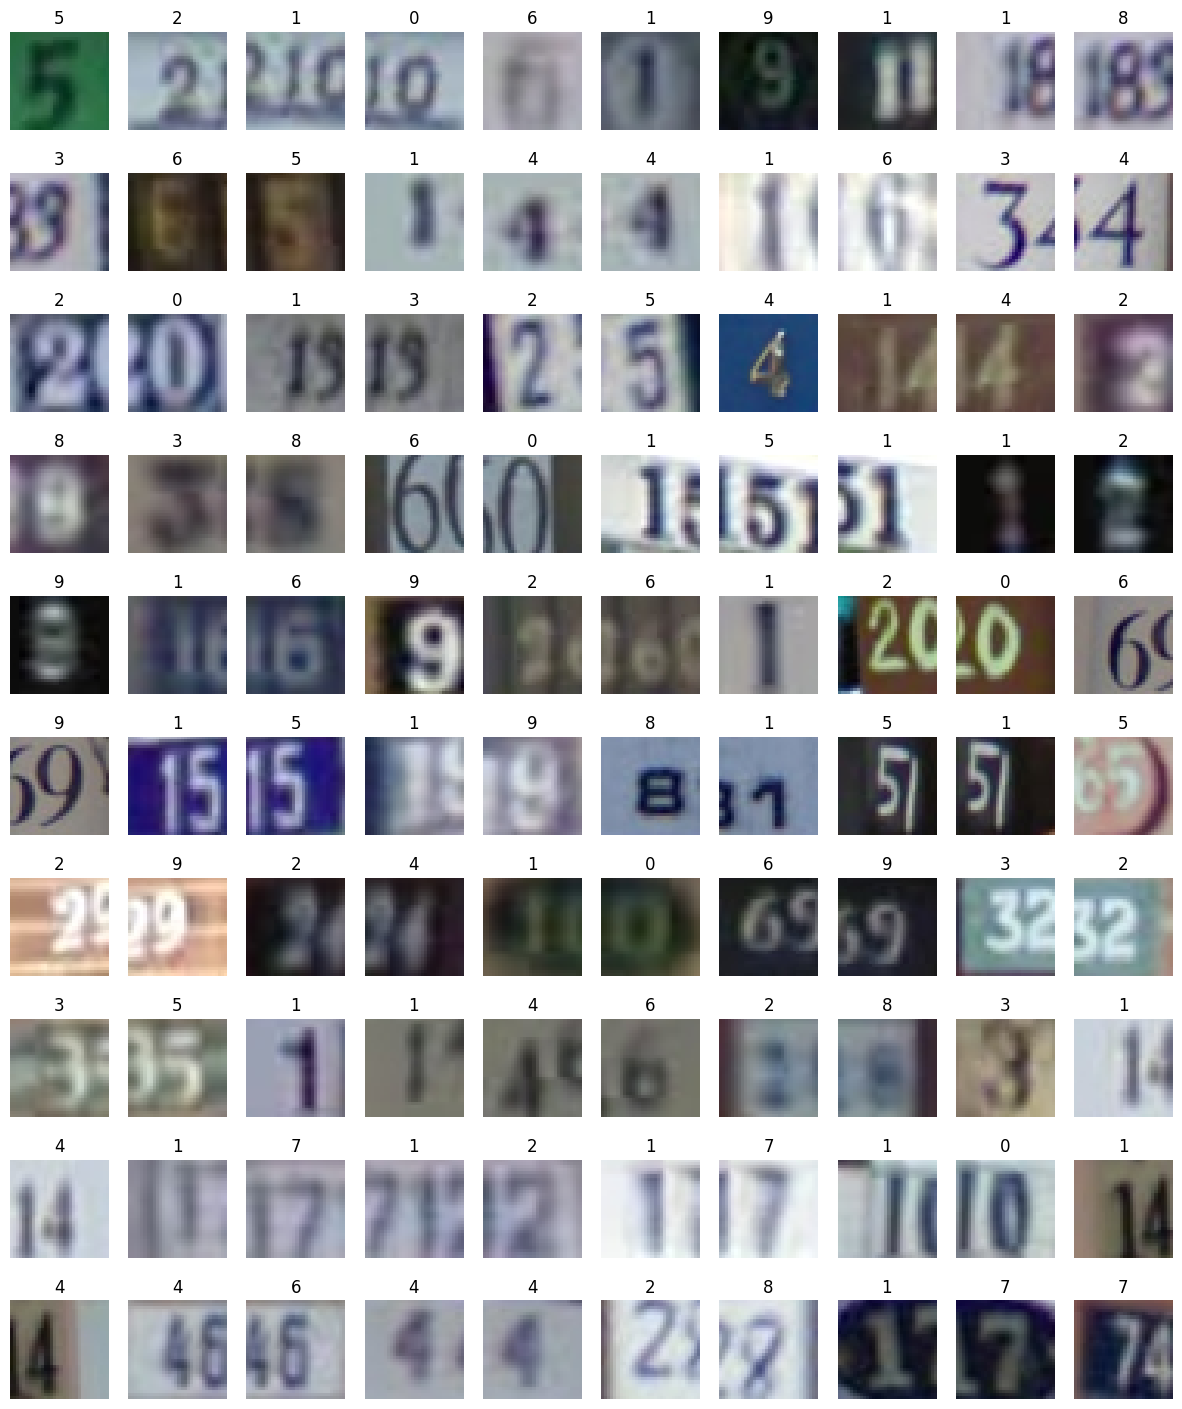

In [81]:
train_X, train_y, val_X, val_y, test_X, test_y = load_data('./data/Q3/q3_train.mat', './data/Q3/q3_validation.mat', './data/Q3/q3_test.mat')

# check shape of data
print(train_X.shape)
print(train_y.shape)
print(val_X.shape)
print(val_y.shape)
print(test_X.shape)
print(test_y.shape)

# visualise images as a sanity check
plot_images(train_X, train_y)

### Vectorise Data

To train an SVM, each sample needs to be a vector rather than an image.

In [82]:
train_vector_X = vectorise(train_X)
val_vector_X = vectorise(val_X)
test_vector_X = vectorise(test_X)
print(train_vector_X.shape)
print(val_vector_X.shape)
print(test_vector_X.shape)

(1000, 3072)
(1000, 3072)
(10000, 3072)


### Conversion and Resizing

You may wish to either:
* Resize images
* Convert images to grayscale

Two functions are provided to do this, and can be used in combination as shown below.

(1000, 20, 20, 1)


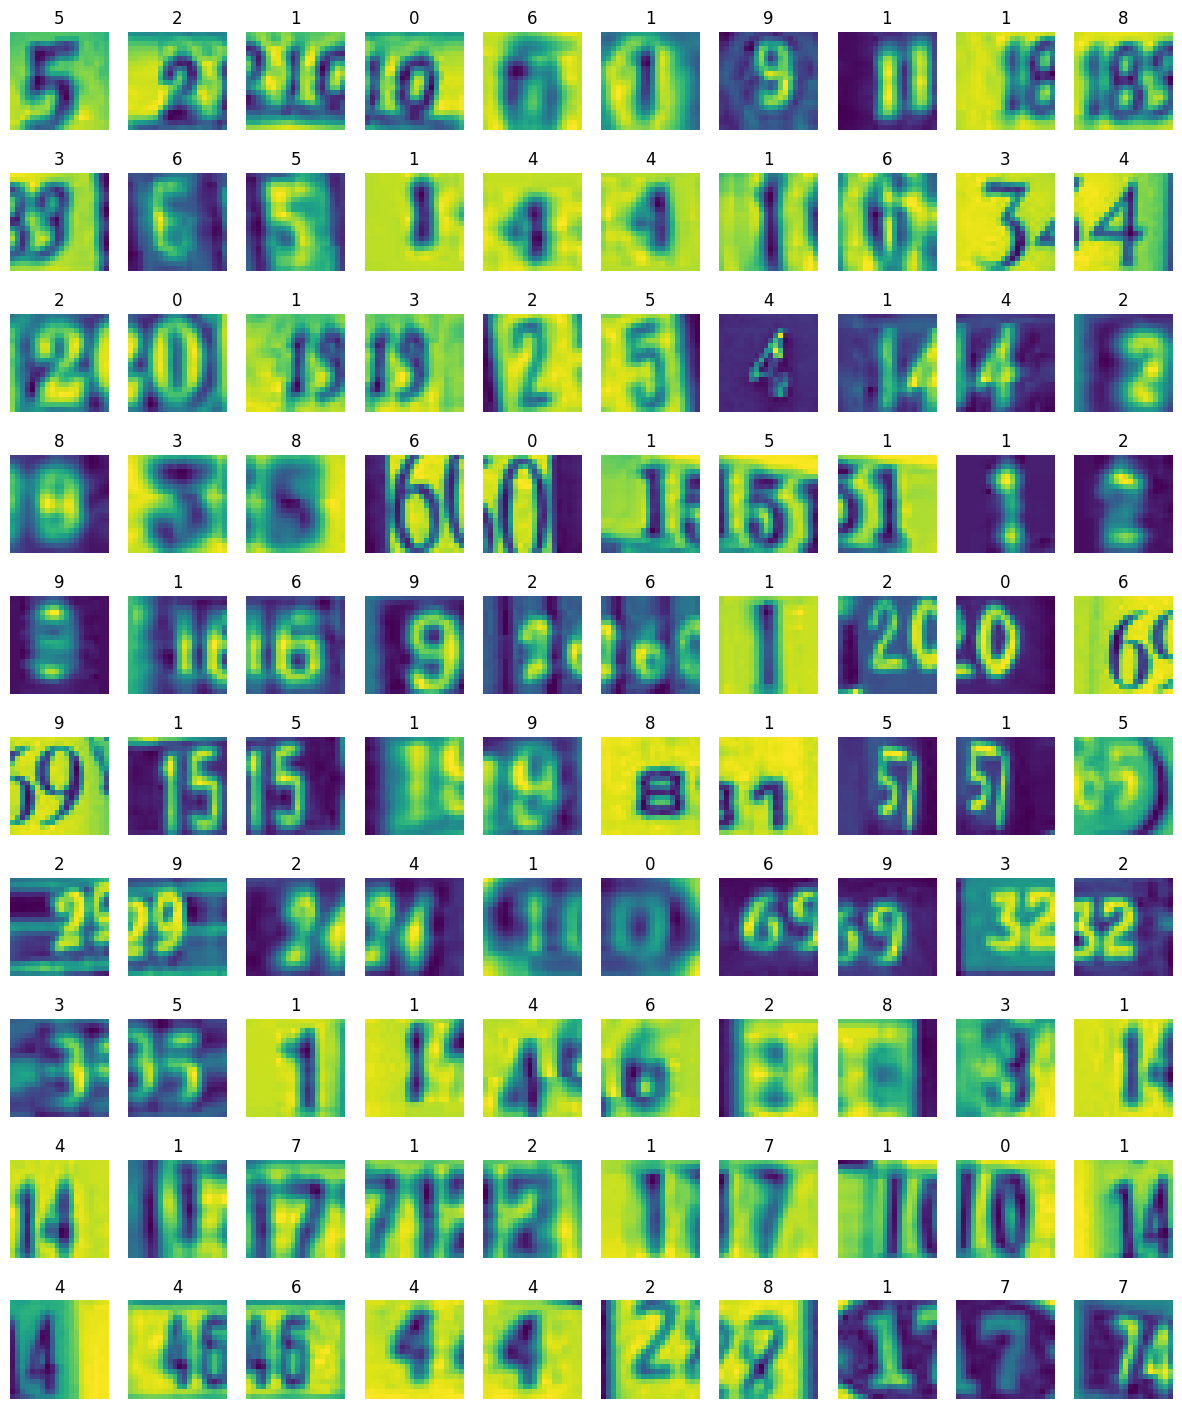

In [83]:
train_X_small = convert_to_grayscale(resize(train_X, (20, 20)))
print(train_X_small.shape)
plot_images(train_X_small, train_y)

### Measuring Time

There are a lot of ways to measure time in python. A simple one is to use ``process_time`` within the ``time`` package. This will simply measure the ellapsed process time in seconds. We can use ths to measure individual parts of our code as follows:

In [84]:
# import process_time
from time import process_time

# get a start time
time_1 = process_time()

# do some stuff, in this case we'll just load some data
train_X, train_y,val_X, val_y, test_X, test_y = load_data('./data/Q3/q3_train.mat', './data/Q3/q3_validation.mat', './data/Q3/q3_test.mat')

# get the end time of our first lot of "stuff"
time_2 = process_time()

# do some other stuff
train_X_small = convert_to_grayscale(resize(train_X, (20, 20)))

# get the end time of our first lot of "stuff"
time_3 = process_time()

# the time it took to do "our stuff" is just the difference between the start and end times
print('Time to load data:   %f seconds' % (time_2 - time_1))
print('Time to resize data: %f seconds' % (time_3 - time_2))

Time to load data:   0.066162 seconds
Time to resize data: 0.016479 seconds


## Question 3 Template

The following provides a starting point for your solution. It trains the SVM that you are to compare your trained DCNNs against, and measures the time taken to train this SVM, and to perform inference with the train and test sets.

This does not measure the performance of the SVM - you will need to implement this as part of your solution.

In [85]:
from sklearn.svm import SVC
from time import process_time

# load data
train_X, train_y,val_X, val_y, test_X, test_y = load_data('./data/Q3/q3_train.mat', './data/Q3/q3_validation.mat', './data/Q3/q3_test.mat')

# any resize, colour change, etc, would go here
# if you do anything, do the same thing to the training, validation, and test sets

# vectorise data
# If you do any resize, reshape, etc of the data prior to putting this into your DCNN, change this code to 
# vectorise that verison of the data. The same data should be used by all models for a fair comparison; though
# you will only vectorise the data for the SVM (i.e. the DCNN will get the data as images).
train_vector_X = vectorise(train_X)
val_vector_X = vectorise(val_X)
test_vector_X = vectorise(test_X)

# train the SVM
# Note that you are not required to tune the SVM, just use it as it is. This also means that we do not need the validation
# set for the SVM as we're not selecting hyper-parameters
# measure the start time of training
svm_train_start = process_time()
# run the training - note that you don't need to change any parameters here except potentially for the input data is you 
# resize, change colour, etc
svm = SVC(C = 1.0, kernel = 'linear').fit(train_vector_X, train_y)
# record the end time of the training
svm_train_end = process_time()
# predict on the training set
train_predictions = svm.predict(train_vector_X)
# measure of the time of the training set prediction
svm_train_pred_end = process_time()
# predict on the test set
test_predictions = svm.predict(test_vector_X)
# measure the end time on the prediction of the test set
svm_test_pred_end = process_time()

# check how long the SVM took to train
svm_train_time = svm_train_end - svm_train_start
# check how long the SVM took to perform inference on the training set
svm_inference_train_time = svm_train_pred_end - svm_train_end
# check how long the SVM took to perform inference on the testing set
svm_inference_test_time = svm_test_pred_end - svm_train_pred_end
# print some times
print('Training Time: %f\nInference Time (training set): %f\nInference Time (testing set): %f' % \
      (svm_train_time, svm_inference_train_time, svm_inference_test_time))

# evaluate SVM
# here you can insert whatever evaluation metrics you feel are appropriate, though F1 and a confusion matrix would be a fair
# option

Training Time: 2.906937
Inference Time (training set): 1.131325
Inference Time (testing set): 11.384695


In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

class ModelEvaluator:
    def __init__(self):
        self.previous_history = []

    def plot_evaluation(self, model, history, val_X, val_y, show_ghost=False, title=None):
        # --- Figure 1: Accuracy & Loss ---
        fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        if title:
            fig1.suptitle(title, fontsize=14, fontweight='bold')

        def plot_metric(ax, current_data, metric_name, title):
            if show_ghost and len(self.previous_history) > 0:
                num_histories = len(self.previous_history)
                for i, hist in enumerate(self.previous_history):
                    ghost_data = hist.history[metric_name]
                    ghost_val_data = hist.history[f'val_{metric_name}']
                    alpha = (i + 1) / (num_histories + 1)
                    ax.plot(ghost_data, color='blue', alpha=alpha, linestyle='--')
                    ax.plot(ghost_val_data, color='orange', alpha=alpha, linestyle='--')

            ax.plot(current_data['train'], label=f'Train {title}')
            ax.plot(current_data['val'], label=f'Val {title}')
            ax.set_title(f'Model {title}')
            ax.legend()
            ax.grid(True, alpha=0.3)

        acc_data = {'train': history.history['accuracy'], 'val': history.history['val_accuracy']}
        plot_metric(ax1, acc_data, 'accuracy', 'Accuracy')

        loss_data = {'train': history.history['loss'], 'val': history.history['val_loss']}
        plot_metric(ax2, loss_data, 'loss', 'Loss')

        plt.tight_layout()
        plt.show()

        # --- Figure 2: Confusion Matrix ---
        fig2, ax3 = plt.subplots(figsize=(8, 6))

        if title:
            fig2.suptitle(title, fontsize=14, fontweight='bold')

        y_pred = np.argmax(model.predict(val_X), axis=1)
        cm = confusion_matrix(val_y, y_pred)

        sns.heatmap(cm, annot=True, fmt='d', ax=ax3, cmap='OrRd')
        ax3.set_title('Confusion Matrix: Predicted vs True')
        ax3.set_xlabel('Predicted')
        ax3.set_ylabel('Actual')

        plt.tight_layout()
        plt.show()

        self.previous_history.append(history)
        self.previous_history = self.previous_history[-5:]

Epoch 1/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1160 - loss: 2.3016 - val_accuracy: 0.1310 - val_loss: 2.2964
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1620 - loss: 2.2882 - val_accuracy: 0.1390 - val_loss: 2.2837
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1640 - loss: 2.2733 - val_accuracy: 0.1380 - val_loss: 2.2682
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1640 - loss: 2.2545 - val_accuracy: 0.1380 - val_loss: 2.2566
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1700 - loss: 2.2416 - val_accuracy: 0.1570 - val_loss: 2.2540
Epoch 6/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2020 - loss: 2.2385 - val_accuracy: 0.1960 - val_loss: 2.2518
Epoch 7/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1900 - loss: 2.2359 - val_accuracy: 0.1940 - val_loss: 2.2488
Epoch 8/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1850 - loss: 2.2331 - val_accuracy: 0.1930 - val_loss:

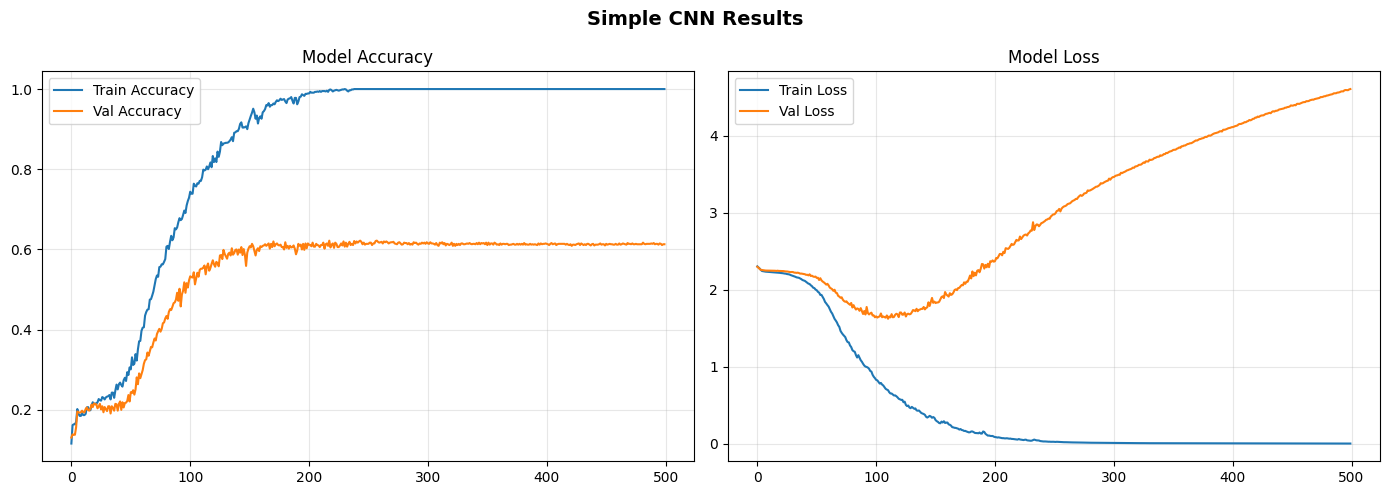

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


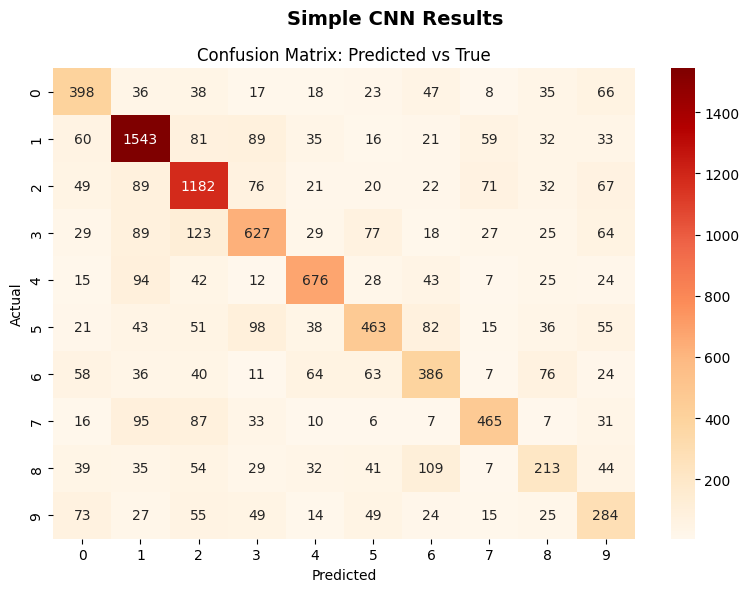

In [87]:
from time import process_time

def get_model():
    inputs = keras.Input(shape=(32, 32, 3, ), name='img')

    x = keras.layers.Conv2D(filters=8, kernel_size=(3,3), activation='relu', padding='same')(inputs)
    x = keras.layers.Conv2D(filters=8, kernel_size=(3,3), activation='relu', padding='same')(x)
    x = keras.layers.MaxPool2D(pool_size=(2, 2))(x)
    
    x = keras.layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu', padding='same')(x)
    x = keras.layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu', padding='same')(x)
    x = keras.layers.MaxPool2D(pool_size=(2, 2))(x)
    
    x = keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same')(x)
    x = keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same')(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(64, activation='relu')(x)
    
    outputs = keras.layers.Dense(10, activation='softmax')(x)
    
    return keras.Model(inputs=inputs, outputs=outputs)

model_cnn = get_model()

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model_cnn.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy'],
    jit_compile=False
)

cnn_train_start_1 = process_time()
history = model_cnn.fit(
    train_X, train_y,
    batch_size=128,
    epochs=500,
    validation_data=(val_X, val_y),
    verbose=True
    #callbacks=[early_stop]
)
cnn_train_time_1 = process_time() - cnn_train_start_1
model_1 = model_cnn

eval = ModelEvaluator()
eval.plot_evaluation(model_1, history, test_X, test_y, title="Simple CNN Results")

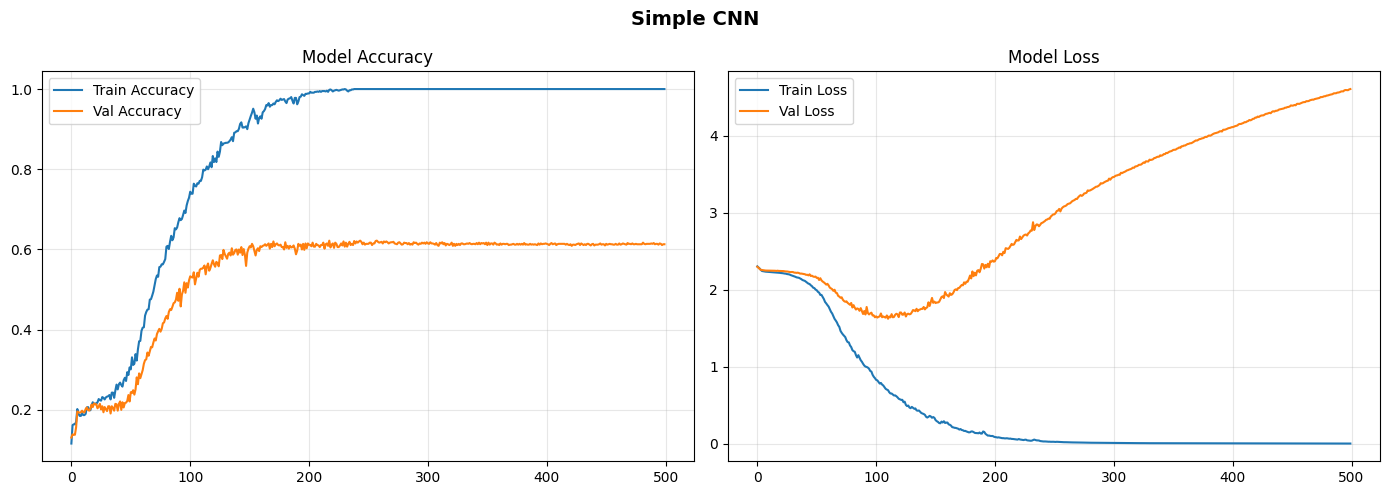

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


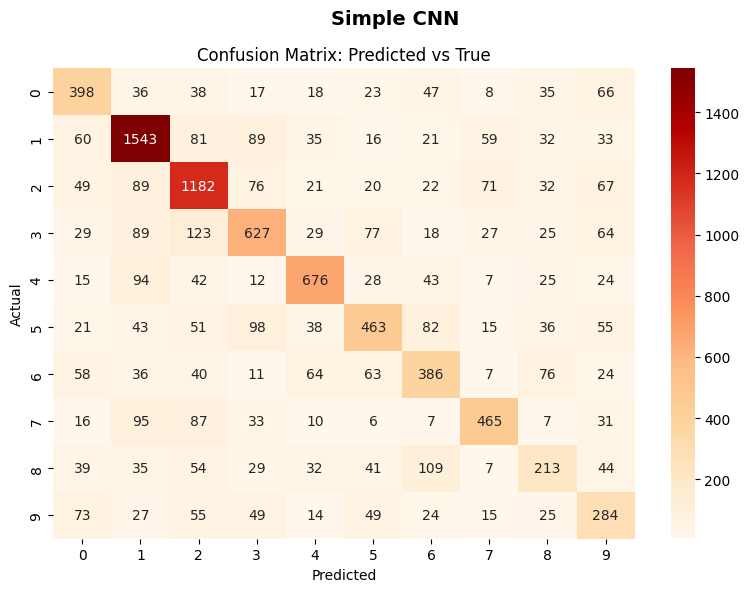

In [93]:
eval.plot_evaluation(model_1, history, test_X, test_y, title="Simple CNN")

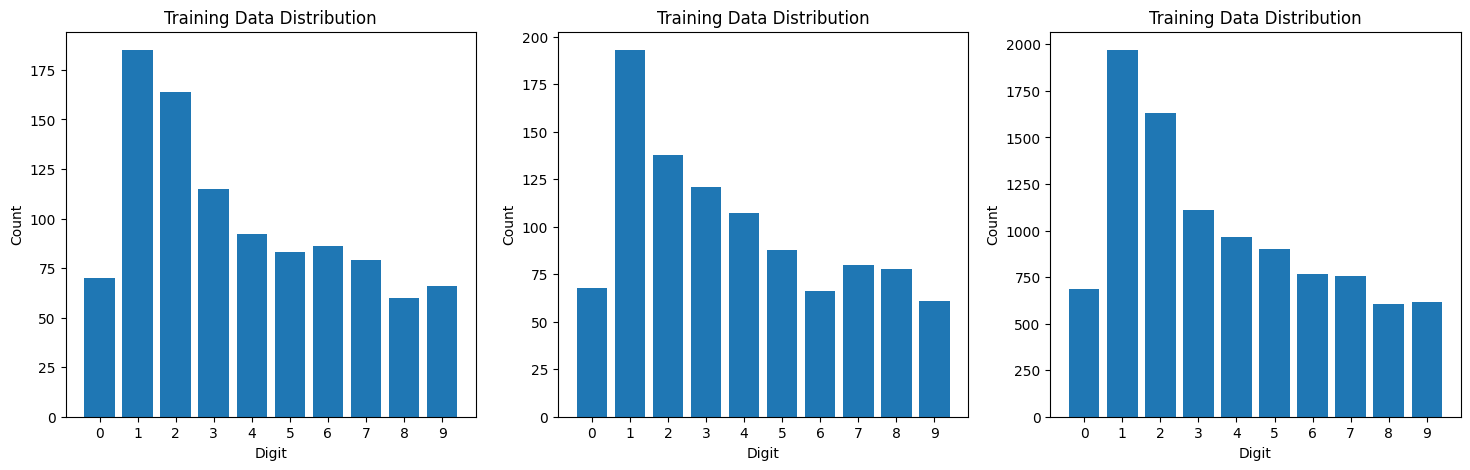

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for axes, arr in [
    (axes[0], train_y),
    (axes[1], val_y),
    (axes[2], test_y)
]:
    unique_values, counts = np.unique(arr, return_counts=True)
    axes.bar(unique_values, counts)
    axes.set_xticks(unique_values)
    axes.set_title('Training Data Distribution')
    axes.set_xlabel('Digit')
    axes.set_ylabel('Count')

plt.show()

From the above plots it can be seen that the distribution of the target variable isn't evenly represented possibly leading to the model not having good predictive capability, I will use data augmentation to make this distribution more even, as each epoch only takes 10ms, we have alot of head room with how much data is created.

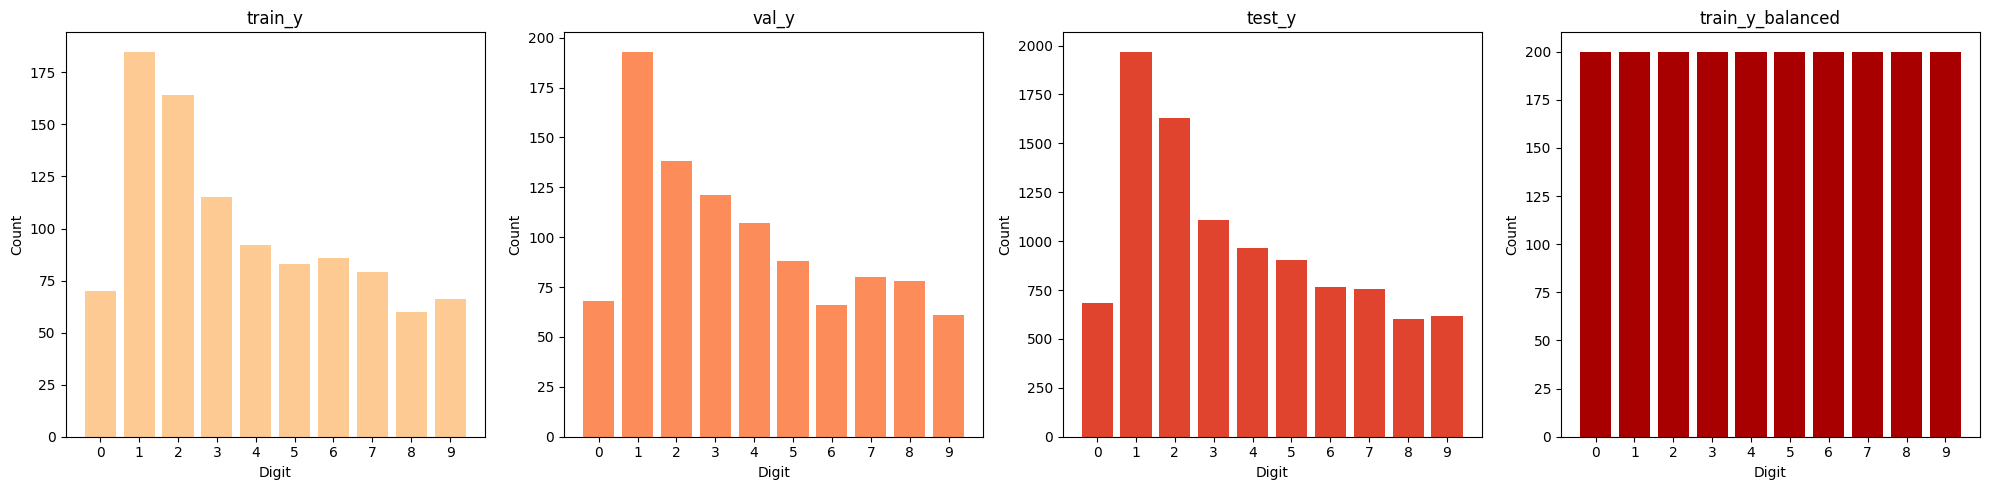

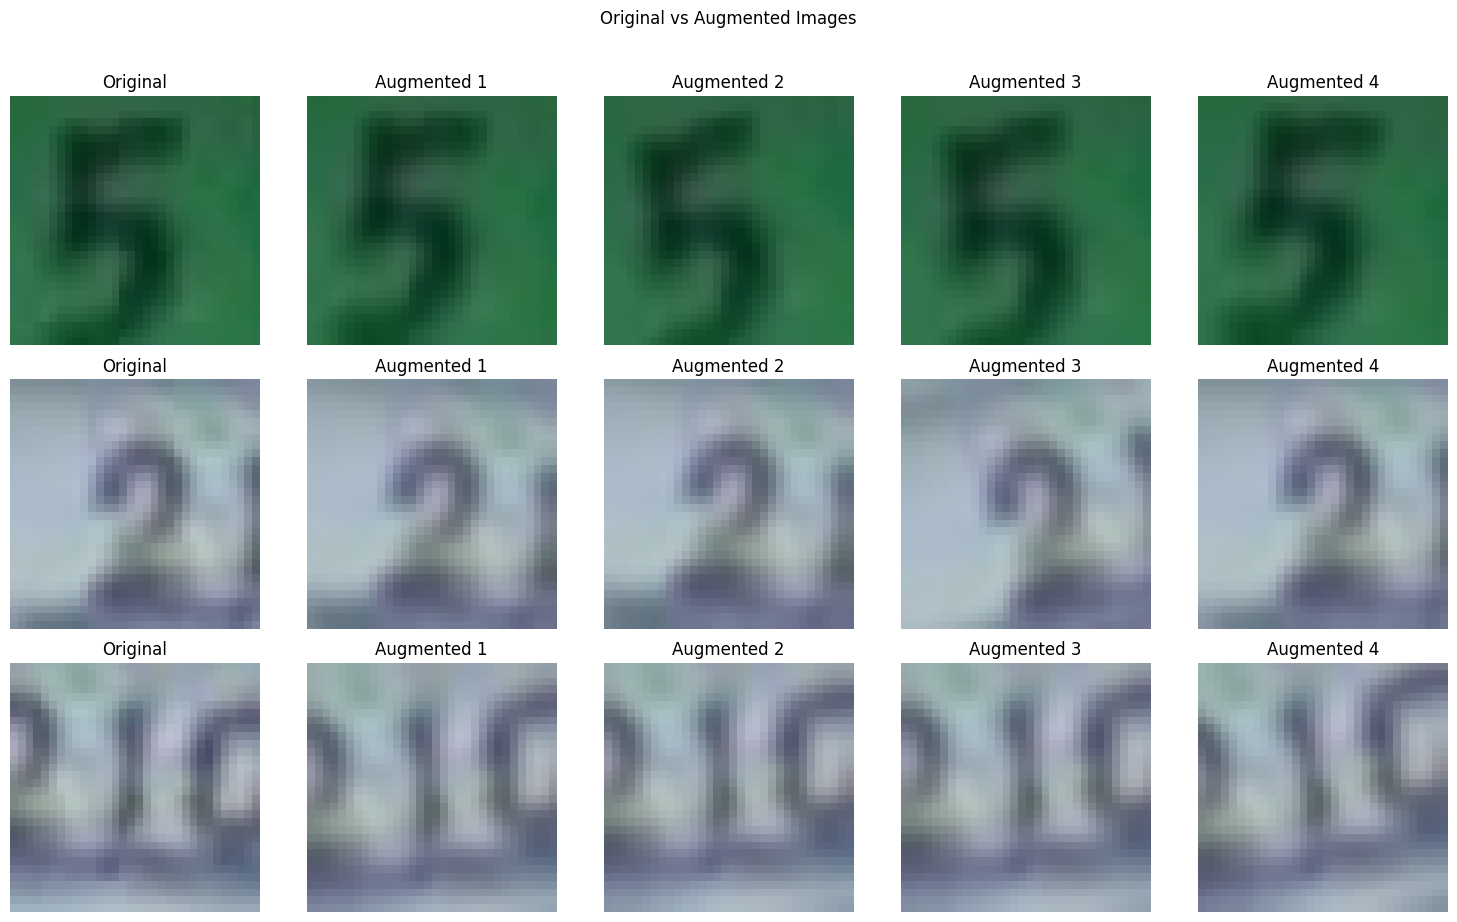

Original train size: 1000
Augmented train size: 2000


In [89]:
augmenter = keras.Sequential([
  keras.layers.RandomRotation(0.05),
  keras.layers.RandomZoom(0.025),
  keras.layers.RandomTranslation(height_factor=(-0.025, 0.025), width_factor=(-0.025, 0.025))
])

unique_classes, counts = np.unique(train_y, return_counts=True)
target_count = 200

balanced_X = []
balanced_y = []

for i in range(10):
    idx = np.where(train_y == i)[0]
    current_images = train_X[idx]
    
    balanced_X.append(current_images)
    balanced_y.append(np.full(len(idx), i))
    
    needed = target_count - len(idx)
    
    if needed > 0:
        random_indices = np.random.choice(len(idx), needed)
        to_augment = current_images[random_indices]
        
        augmented_images = augmenter(to_augment, training=True).numpy()
        
        balanced_X.append(augmented_images)
        balanced_y.append(np.full(needed, i))

train_X_balanced = np.concatenate(balanced_X)
train_y_balanced = np.concatenate(balanced_y)

# One distinct OrRd colour per dataset
orrd = plt.get_cmap('OrRd')
dataset_colours = orrd(np.linspace(0.3, 0.9, 4))

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, arr, title, colour in zip(
    axes,
    [train_y, val_y, test_y, train_y_balanced],
    ["train_y", "val_y", "test_y", "train_y_balanced"],
    dataset_colours,
):
    unique_values, counts = np.unique(arr, return_counts=True)
    ax.bar(unique_values, counts, color=colour)
    ax.set_xticks(unique_values)
    ax.set_title(title)
    ax.set_xlabel('Digit')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

# 3 rows: 1 original + 4 augmented versions per row
source_images = train_X[:3]

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for row, orig in enumerate(source_images):
    img_batch = np.stack([orig] * 4)
    augmented = augmenter(img_batch, training=True).numpy()
    axes[row, 0].imshow(orig.squeeze(), cmap='gray')
    axes[row, 0].set_title('Original')
    axes[row, 0].axis('off')
    for col in range(4):
        axes[row, col + 1].imshow(augmented[col].squeeze(), cmap='gray')
        axes[row, col + 1].set_title(f'Augmented {col + 1}')
        axes[row, col + 1].axis('off')

plt.suptitle('Original vs Augmented Images', y=1.02)
plt.tight_layout()
plt.show()

print("Original train size:", len(train_y))
print("Augmented train size:", len(train_y_balanced))


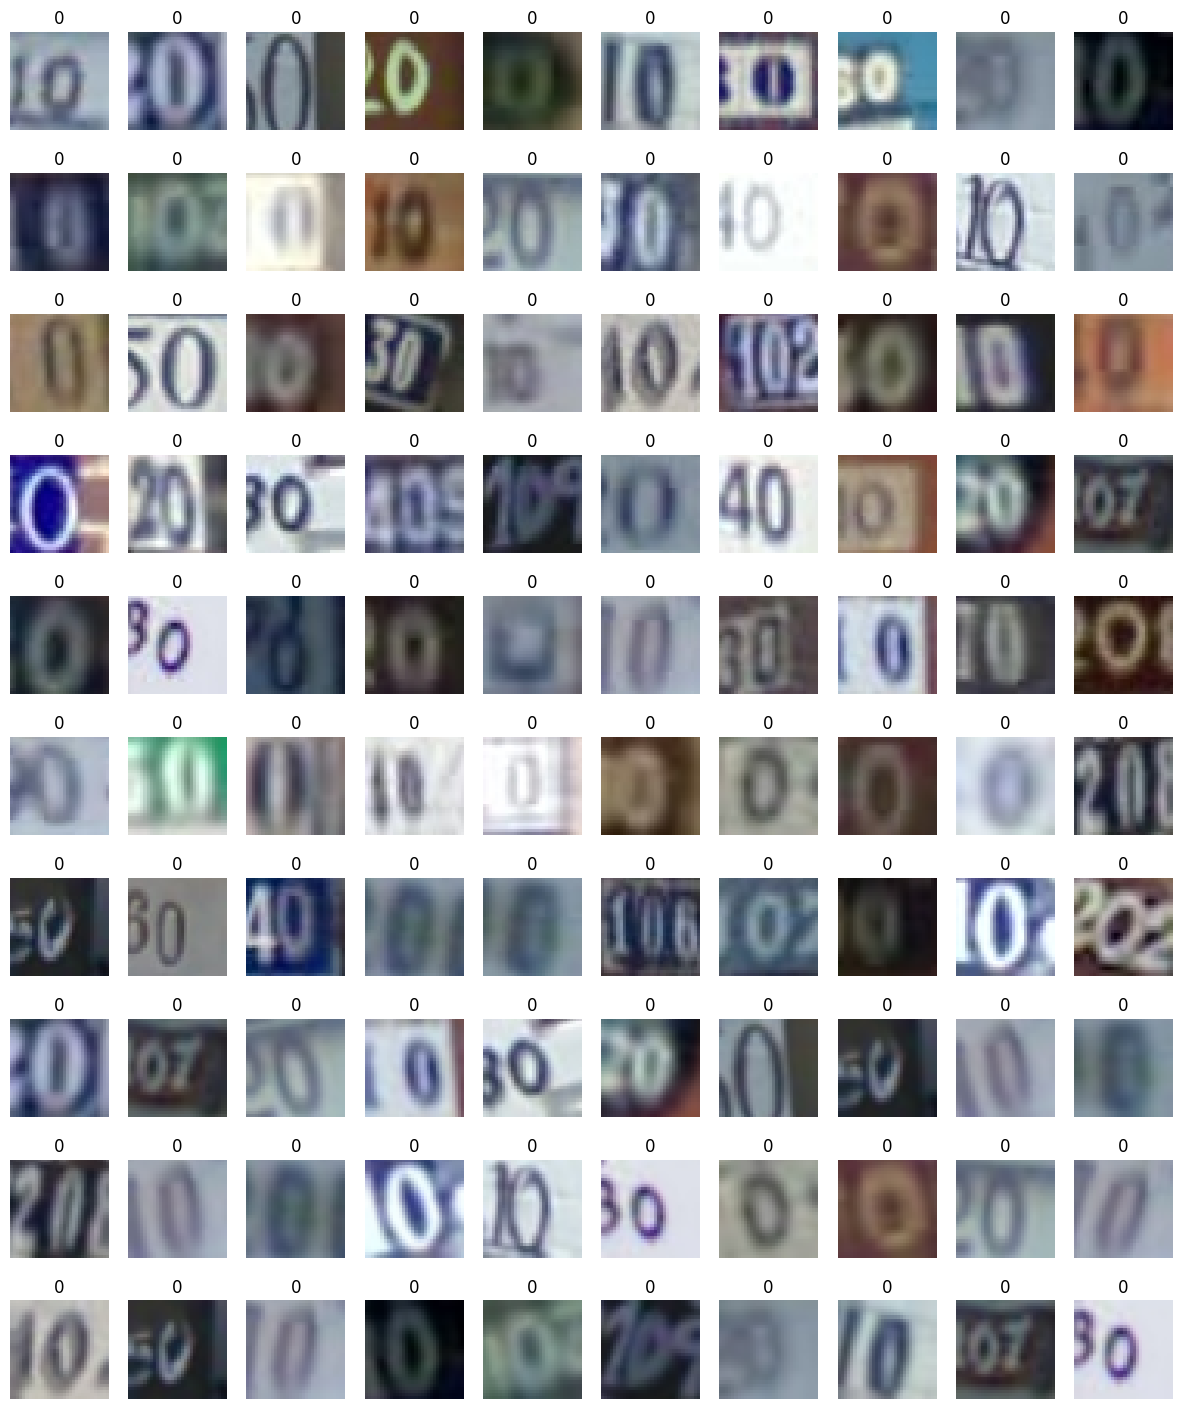

In [90]:
plot_images(train_X_balanced, train_y_balanced)

In [91]:
#cnn_train_start_2 = process_time()
#history = model_cnn.fit(
#    train_X_balanced, train_y_balanced,
#    batch_size=128,
#    epochs=500,
#    validation_data=(val_X, val_y),
#    verbose=True
#    #callbacks=[early_stop]
#)
#cnn_train_time_2 = process_time() - cnn_train_start_2
#model_2 = model_cnn
#
#eval_2 = eval
#eval_2.plot_evaluation(model_cnn, history, test_X, test_y, show_ghost=True)

Epoch 1/500


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.1195 - loss: 36.6129 - val_accuracy: 0.1070 - val_loss: 35.4799
Epoch 2/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1045 - loss: 34.7405 - val_accuracy: 0.1070 - val_loss: 33.6953
Epoch 3/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1150 - loss: 32.9292 - val_accuracy: 0.1070 - val_loss: 31.9430
Epoch 4/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1160 - loss: 31.1866 - val_accuracy: 0.1070 - val_loss: 30.2330
Epoch 5/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1270 - loss: 29.4806 - val_accuracy: 0.1070 - val_loss: 28.5687
Epoch 6/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1230 - loss: 27.8342 - val_accuracy: 0.1070 - val_loss: 26.9529
Epoch 7/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1295 - loss: 26.2361 - val_accuracy: 0.1070 - val_loss: 25.3860
Epoch 8/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1260 - loss: 24.6766 - val_accuracy:

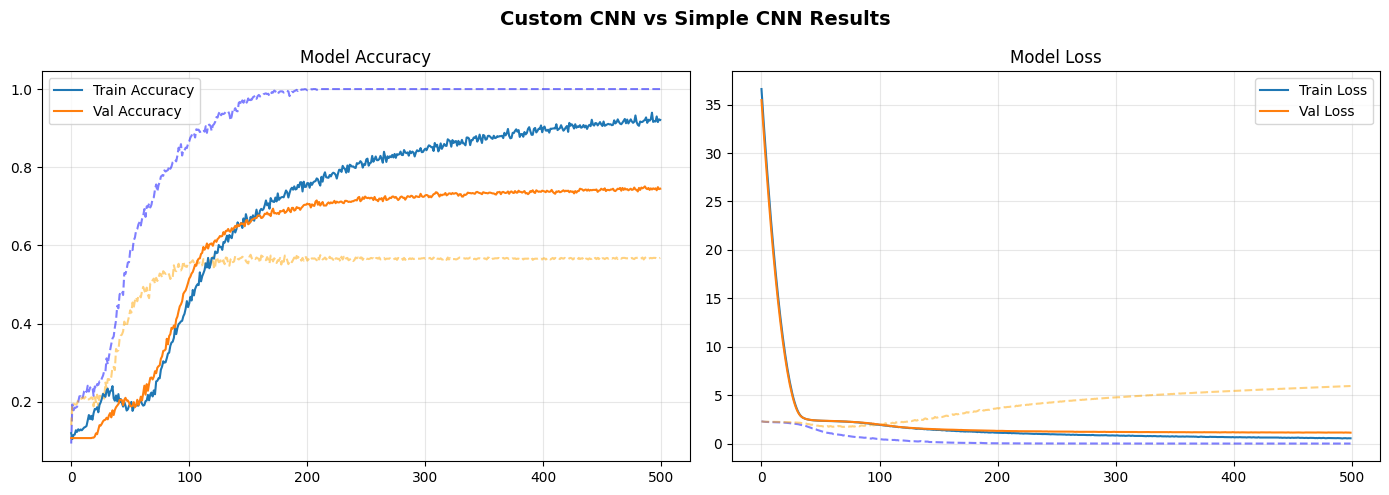

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


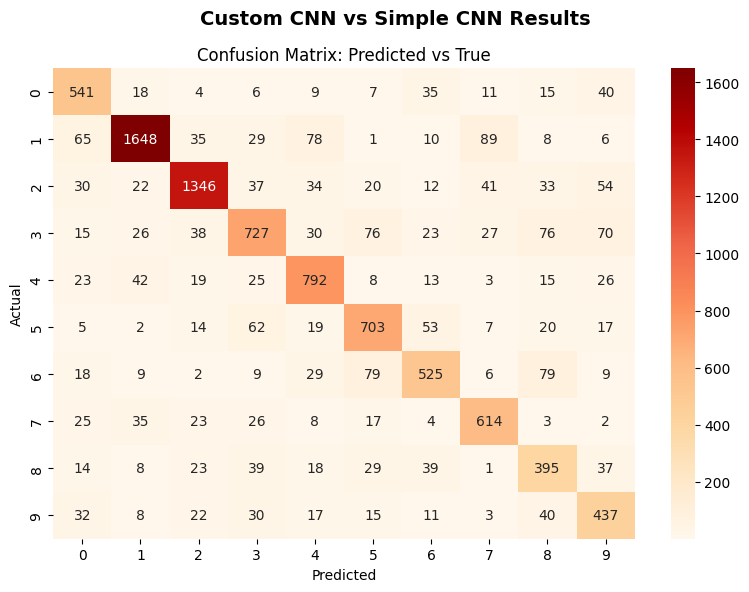

In [74]:
def get_model():
    inputs = keras.Input(shape=(32, 32, 3, ), name='img')
    x = keras.layers.Conv2D(filters=8, kernel_size=(3,3), activation=None, padding='same')(inputs)
    x = keras.layers.Activation(keras.activations.swish)(x)
    x = keras.layers.Conv2D(filters=8, kernel_size=(3,3), activation=None, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation(keras.activations.swish)(x)
    x = keras.layers.SpatialDropout2D(0.2)(x)
    x = keras.layers.MaxPool2D(pool_size=(2, 2))(x)

    x = keras.layers.Conv2D(filters=16, kernel_size=(3,3), activation=None, padding='same')(x)
    x = keras.layers.Activation(keras.activations.swish)(x)
    x = keras.layers.Conv2D(filters=16, kernel_size=(3,3), activation=None, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation(keras.activations.swish)(x)
    x = keras.layers.SpatialDropout2D(0.2)(x)
    x = keras.layers.MaxPool2D(pool_size=(2, 2))(x)

    x = keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation=None, padding='same')(x)
    x = keras.layers.Activation(keras.activations.swish)(x)
    x = keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation=None, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation(keras.activations.swish)(x)
    x = keras.layers.SpatialDropout2D(0.2)(x)

    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(64, activation=None, kernel_regularizer='l1')(x)
    x = keras.layers.Activation(keras.activations.swish)(x)
    outputs = keras.layers.Dense(10, activation='softmax')(x)
    
    return keras.Model(inputs=inputs, outputs=outputs)

model_cnn = get_model()

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model_cnn.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy'],
    jit_compile=False
)

cnn_train_start_2 = process_time()
history = model_cnn.fit(
    train_X_balanced, train_y_balanced,
    batch_size=128,
    epochs=500,
    validation_data=(val_X, val_y),
    verbose=True
    #callbacks=[early_stop]
)
cnn_train_time_2 = process_time() - cnn_train_start_2


model_2 = model_cnn

eval_3 = eval
eval_3.plot_evaluation(model_2, history, test_X, test_y, show_ghost=True, title="Custom CNN vs Simple CNN Results")

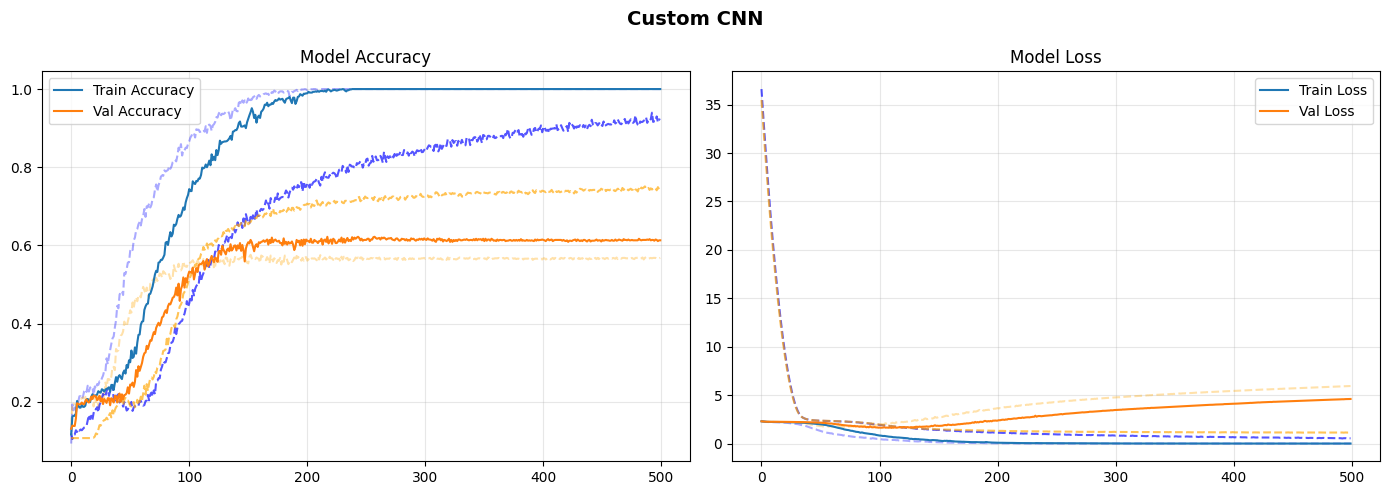

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


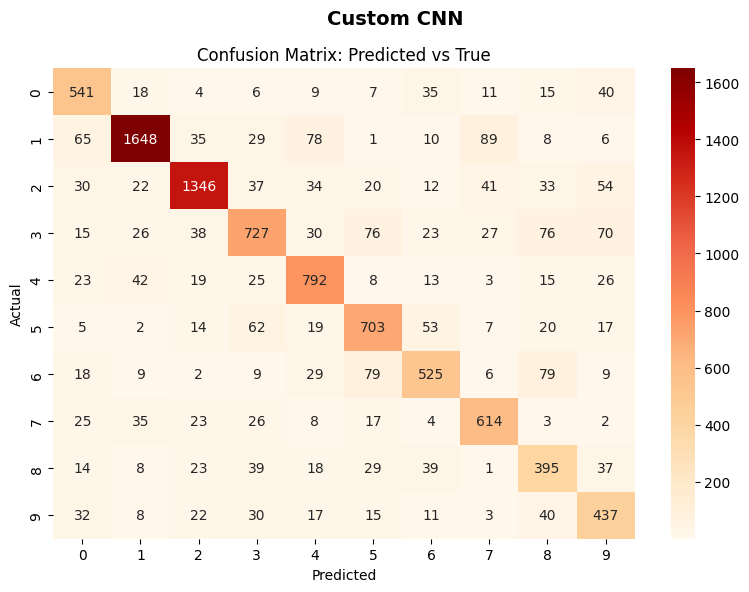

In [92]:
eval_3.plot_evaluation(model_2, history, test_X, test_y, show_ghost=True, title="Custom CNN")

In [75]:
import tensorflow as tf
import pydot

tf.keras.utils.plot_model(
    model_cnn,
    to_file="Fig3.2.png",
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    show_layer_activations=True,
    expand_nested=True,
    dpi=150,
)


You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [76]:
# For your write-up, you should include:
# - briefly mention any pre-processing you did and why
# - outline your network design, and training approach. The discussion of training should note how long the model was trained
#   for, and if it converged. If you observe the non-augmented and augmented networks training at different rates, discuss that
#   here
# - outline your data augmentation, and briefly justify why these methods were chosen.
# - an evaluation and comparison of three models, which should highlight any differences observed between the models, and the
#   inference time of the three models
# Your write-up should be supported by appropriate figures and tables. Figures and tables should have numbers and meaningful captions.
# Note that figures and tables are not included in the page limits.
#
# SEE THE ASSIGNMENT BRIEF ON CANVAS FOR MORE DETAILS AND NOTE THAT A NOTEBOOK FILE DOES NOT CONSTITUTE A VALID SUBMISSION. 
# YOU SHOULD WRITE UP YOUR RESPONSE IN A SEPARATE DOCUMENT

In [77]:
# Table 3.2 - Model Comparison
from time import process_time

def time_inference(model, X, batch_size=128, runs=3):
    model.predict(X[:1], verbose=0)  # warm up
    times = []
    for _ in range(runs):
        t0 = process_time()
        model.predict(X, batch_size=batch_size, verbose=0)
        times.append(process_time() - t0)
    return np.mean(times)

# Inference times
svm_inf_time   = svm_inference_test_time
cnn_inf_time_1 = time_inference(model_1, test_X)
cnn_inf_time_2 = time_inference(model_2, test_X)

# Test accuracies
svm_acc  = np.mean(svm.predict(test_vector_X) == test_y)
cnn_acc_1 = np.mean(np.argmax(model_1.predict(test_X, verbose=0), axis=1) == test_y)
cnn_acc_2 = np.mean(np.argmax(model_2.predict(test_X, verbose=0), axis=1) == test_y)

print("Table 3.2: Model Comparison")
print(f"{'Model':<35} {'Test Acc':>10} {'Train Time':>12} {'Inference Time':>16}")
print("-" * 76)
print(f"{'SVM (baseline)':<35} {svm_acc:>10.4f} {svm_train_time:>11.2f}s {svm_inf_time:>15.2f}s")
print(f"{'Model 1: CNN, no augmentation':<35} {cnn_acc_1:>10.4f} {cnn_train_time_1:>11.2f}s {cnn_inf_time_1:>15.2f}s")
print(f"{'Model 2: Custom CNN, augmentation':<35} {cnn_acc_2:>10.4f} {cnn_train_time_2:>11.2f}s {cnn_inf_time_2:>15.2f}s")

Table 3.2: Model Comparison
Model                                 Test Acc   Train Time   Inference Time
----------------------------------------------------------------------------
SVM (baseline)                          0.1861        2.85s           11.39s
Model 1: CNN, no augmentation           0.5857       90.39s            0.45s
Model 2: Custom CNN, augmentation       0.7728      154.30s            0.48s
